In [3]:
pip install fredapi

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [47]:
def use_chart_style():
    import matplotlib as mpl
    from cycler import cycler

    mpl.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Lato", "DejaVu Sans"],

        # ▸ 4-color cycle (blue, amber, teal, slate)
        "axes.prop_cycle": cycler(color=[
            "#2D6A8C",   # deep muted blue
            "#F2AA52",   # soft amber
            "#6C8E8E",   # muted teal
            "#9099A2",   # cool slate-grey
        ]),

        "axes.titlesize": 16,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "lines.linewidth": 2.4,
        "grid.color": "#CCCCCC",
        "grid.linestyle": "--",
        "axes.grid": True,
        "figure.facecolor": "#FAF3E0",
        "axes.facecolor":  "#FAF3E0",
        "savefig.facecolor": "#FAF3E0",
        "figure.autolayout": True,
    })

/var/folders/43/9kgwqynj2f1b73147f7w9gj00000gn/T/ipykernel_52790/1123151198.py:17: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  base = fred.get_series("BOGMBASE", observation_start=start).resample("Q").last()


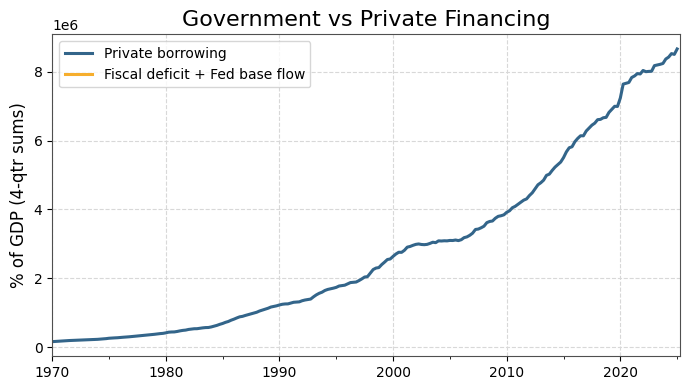

In [16]:
from fredapi import Fred
import pandas as pd, matplotlib.pyplot as plt, datetime as dt

FRED_KEY = "b1b93f854d911b3cdc94df6dd9ec0365"   # ← your 32-char key
fred = Fred(api_key=FRED_KEY)                   # use the variable here

start = "1970-01-01"; end = dt.date.today()

# Private-sector borrowing (% GDP, quarterly)
priv = fred.get_series("NCBDBIQ027S", observation_start=start)

# Federal deficit (% GDP) – values are negative for deficits
fisc_pct = fred.get_series("FYFSGDA188S", observation_start=start)
fisc_pct = -fisc_pct        # flip sign so ↑ = more fiscal easing

# Fed base money → 12-m Δ → % GDP
base = fred.get_series("BOGMBASE", observation_start=start).resample("Q").last()
gdp  = fred.get_series("GDP",      observation_start=start)
base_flow_pct = base.diff(4) / gdp * 100

# --- Plot ---
ax = priv.plot(figsize=(7,4), label="Private borrowing")
(fisc_pct + base_flow_pct).plot(ax=ax,
                                label="Fiscal deficit + Fed base flow")
ax.set_title("Government vs Private Financing")
ax.set_ylabel("% of GDP (4-qtr sums)")
ax.legend(); plt.show()

In [34]:
from fredapi import Fred
import matplotlib.pyplot as plt, datetime as dt
import yfinance as yf

fred = Fred(api_key="b1b93f854d911b3cdc94df6dd9ec0365")

start = "1985-01-01"
end   = dt.date.today()

# 1) U.S. market-cap as % U.S. GDP  (annual, already %)
us_pct_usgdp = fred.get_series("DDDM01USA156NWDB", start)

# 2) U.S. GDP ($, SAAR)  → annual level
us_gdp = fred.get_series("GDP", start).resample("YE").last()

# 3) **World GDP ($, current)**  — FRED hosts WDI codes with dots removed
world_gdp = fred.get_series("NYGDPMKTPCDWLD", start).resample("YE").last()

# 4) Convert U.S. market-cap to % of **world** GDP
us_mcap_lvl      = (us_pct_usgdp / 100) * us_gdp
us_pct_worldgdp  = (us_mcap_lvl / world_gdp) * 100
us_pct_worldgdp.name = "USA"

# Optional “Other DM” proxy — MSCI World ex-US price *roughly* scaled
exus_idx = yf.download("^W1DOW", start=start)["Adj Close"].resample("YE").last()
exus_pct_world = (exus_idx / 1e12) / world_gdp * 100     # crude $-scaling
exus_pct_world.name = "Other DM (proxy)"

# ——— plot ———
ax = us_pct_worldgdp.plot(figsize=(7,4))
exus_pct_world.plot(ax=ax, linestyle="--")
ax.set_title("Market-Cap Relative to World GDP")
ax.set_ylabel("% of World GDP")
ax.legend(); plt.show()

/var/folders/43/9kgwqynj2f1b73147f7w9gj00000gn/T/ipykernel_52790/798362063.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  exus_idx = yf.download("^W1DOW", start=start)["Adj Close"].resample("YE").last()
[*********************100%***********************]  1 of 1 completed


KeyError: 'Adj Close'

/var/folders/43/9kgwqynj2f1b73147f7w9gj00000gn/T/ipykernel_52790/355966942.py:9: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  net_worth = fred.get_series("TNWBSHNO", start).resample("Q").last()
/var/folders/43/9kgwqynj2f1b73147f7w9gj00000gn/T/ipykernel_52790/355966942.py:10: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  gdp       = fred.get_series("GDP",       start).resample("Q").last()
/var/folders/43/9kgwqynj2f1b73147f7w9gj00000gn/T/ipykernel_52790/355966942.py:11: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  disp_inc  = fred.get_series("DSPIC96",   start).resample("Q").last()


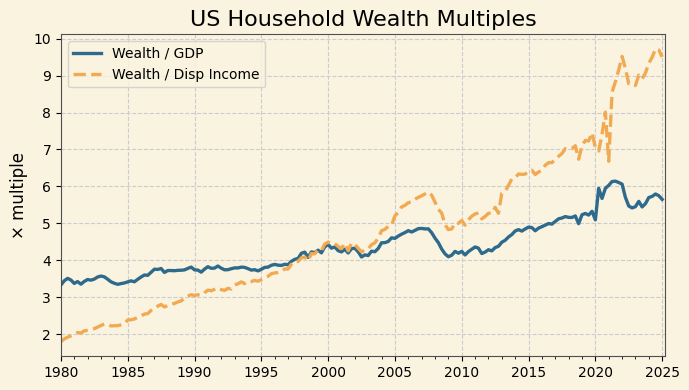

In [49]:
from fredapi import Fred
import matplotlib.pyplot as plt

use_chart_style()  # <--  guarantee palette & font right before plotting

fred  = Fred(api_key="b1b93f854d911b3cdc94df6dd9ec0365")
start = "1980-01-01"

net_worth = fred.get_series("TNWBSHNO", start).resample("Q").last()
gdp       = fred.get_series("GDP",       start).resample("Q").last()
disp_inc  = fred.get_series("DSPIC96",   start).resample("Q").last()

(net_worth / gdp).rename("Wealth / GDP").plot(figsize=(7,4))
(net_worth / disp_inc).rename("Wealth / Disp Income").plot(linestyle="--")

plt.title("US Household Wealth Multiples")
plt.ylabel("× multiple")
plt.legend()
plt.show()

/var/folders/43/9kgwqynj2f1b73147f7w9gj00000gn/T/ipykernel_52790/2173371778.py:20: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'Y' instead.
  income_y.index = income_y.index.to_period("A").to_timestamp("A")  # shift to 31-Dec


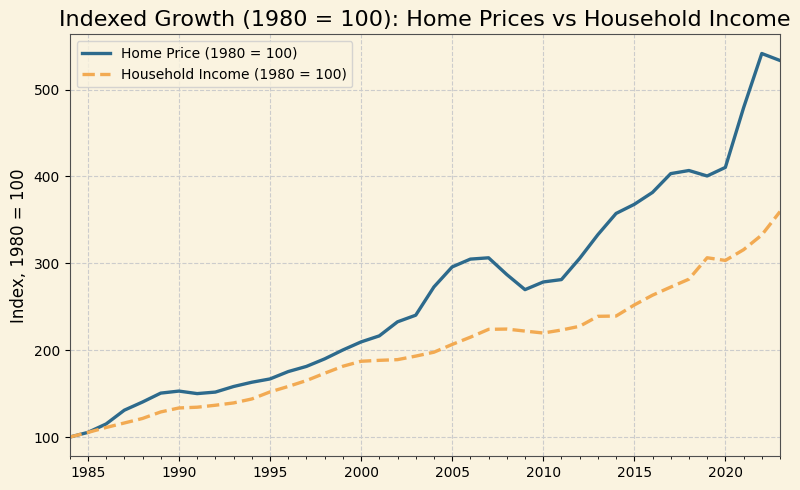

In [40]:
# 
# Indexed growth since 1980 (1980 = 100): Median Home Price vs Household Income
# 
import pandas as pd, matplotlib.pyplot as plt, datetime as dt
from fredapi import Fred

use_chart_style()      # make sure the custom palette / font / background is active

fred   = Fred(api_key="b1b93f854d911b3cdc94df6dd9ec0365")
start  = "1980-01-01"
end    = dt.date.today()

house_raw = fred.get_series("MSPUS", start, end)            # quarterly $
income_raw = fred.get_series("MEHOINUSA646N", start, end)   # annual $

house_y = house_raw.resample("YE").mean()
income_y = income_raw.copy()
income_y.index = income_y.index.to_period("A").to_timestamp("A")  # shift to 31-Dec

df = pd.concat([house_y, income_y], axis=1).dropna()
df.columns = ["Home Price", "Household Income"]

base_values = df.iloc[0]
idx_df = df.divide(base_values) * 100

# Plot ---------------------------------------------------------------------
ax = idx_df["Home Price"].plot(figsize=(8,5), label="Home Price (1980 = 100)")
idx_df["Household Income"].plot(ax=ax, label="Household Income (1980 = 100)",
                                linestyle="--")

ax.set_title("Indexed Growth (1980 = 100): Home Prices vs Household Income")
ax.set_ylabel("Index, 1980 = 100")
ax.grid(axis="y", linestyle="--")
ax.legend(loc="upper left")

plt.show()

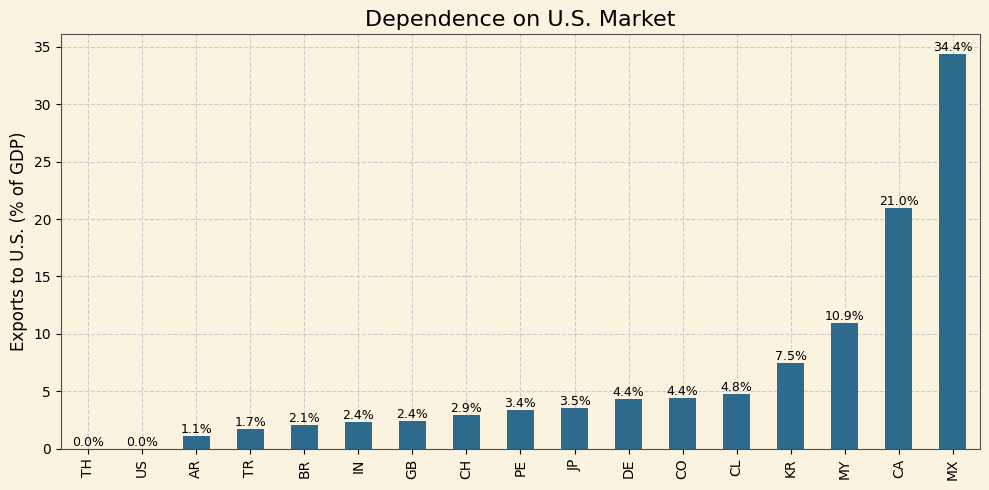

In [41]:
# Exports-to-U.S. as % of GDP  —  smallest to largest (bar chart)
import pandas as pd, matplotlib.pyplot as plt

use_chart_style()   

data = {
    "TH": 0,
    "US": 0,
    "AR": 1.081666667,
    "TR": 1.684591837,
    "BR": 2.073947368,
    "IN": 2.372823529,
    "GB": 2.377402597,
    "CH": 2.912761111,
    "PE": 3.385714286,
    "JP": 3.5425,
    "DE": 4.368225,
    "CO": 4.397647059,
    "CL": 4.7953125,
    "KR": 7.464588235,
    "MY": 10.94607843,
    "CA": 20.99759615,
    "MX": 34.36226667,
}

df = pd.Series(data, name="% of GDP").sort_values()

fig, ax = plt.subplots(figsize=(10,5))
df.plot(kind="bar", ax=ax)

ax.set_ylabel("Exports to U.S. (% of GDP)")
ax.set_title("Dependence on U.S. Market")
ax.grid(axis="y", linestyle="--")
ax.set_axisbelow(True)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=9)

plt.show()

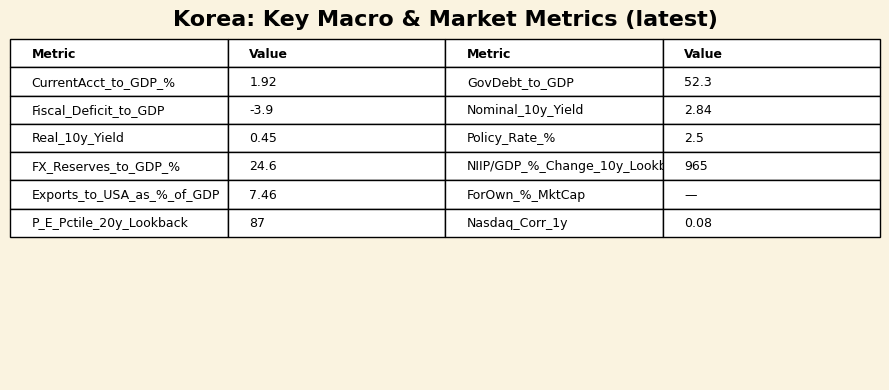

In [88]:
# “Macro Snapshot – Korea”  (beige placemat graphic, no scrolling required)
import matplotlib.pyplot as plt
import pandas as pd

use_chart_style()   
row = {
    "Country"                       : "KR",
    "CurrentAcct_to_GDP_%"          : 1.92,
    "GovDebt_to_GDP"                : 52.3,
    "Fiscal_Deficit_to_GDP"         : -3.9,
    "Nominal_10y_Yield"             : 2.84,
    "Real_10y_Yield"                : 0.45,
    "Policy_Rate_%"                 : 2.5,
    "FX_Reserves_to_GDP_%"          : 24.60,
    "NIIP/GDP_%_Change_10y_Lookback": 965,
    "Exports_to_USA_as_%_of_GDP"    : 7.46,
    "ForOwn_%_MktCap"               : "—",   # missing
    "P_E_Pctile_20y_Lookback"       : 87,
    "Nasdaq_Corr_1y"                : 0.08,
}

items = list(row.items())[1:]  # skip Country label
pairs = [items[i:i+2] for i in range(0, len(items), 2)]

fig, ax = plt.subplots(figsize=(9,4))
fig.patch.set_facecolor("#FAF3E0")
ax.axis("off")

tbl = ax.table(
    cellText   = table_data,
    colLabels  = ["Metric", "Value", "Metric", "Value"],
    colLoc     = "left",
    cellLoc    = "left",
    loc        = "upper center",     # <-- push table up
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.5)

# Bold header
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.get_text().set_weight("bold")

# Title snug against the table
ax.set_title("Korea: Key Macro & Market Metrics (latest)",
             y=1.02, pad=0, fontweight="bold")   # y > 1 moves it upward slightly

plt.tight_layout()
plt.show()

Request URL: https://api.fiscaldata.treasury.gov/services/api/fiscal_service/v1/debt/mspd/mspd_table_1
Unique security_class_desc values in the dataset:
Data after categorization (first 5 rows):
Annual Outstanding Debt by Type (Year-End):
category          Bill          Bond          Note         Other  \
year                                                               
2006      9.442235e+11  5.306820e+11  2.441860e+12  2.171271e+13   
2007      1.003875e+12  5.585378e+11  2.488487e+12  2.316493e+13   
2008      1.866666e+12  5.951317e+11  2.792206e+12  2.631528e+13   
2009      1.793480e+12  7.184234e+11  4.181108e+12  2.967298e+13   
2010      1.772528e+12  8.931324e+11  5.571749e+12  3.322213e+13   

category          Tips          year  
year                                  
2006      4.111929e+11  2.006000e+09  
2007      4.716861e+11  2.007000e+09  
2008      5.301301e+11  2.008000e+09  
2009      5.680553e+11  2.009000e+09  
2010      6.161055e+11  2.010000e+09  
Percentage 

/var/folders/43/9kgwqynj2f1b73147f7w9gj00000gn/T/ipykernel_52790/3165586070.py:85: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  annual_data = daily_pivot.groupby("year").apply(lambda g: g.loc[g.index.max()])


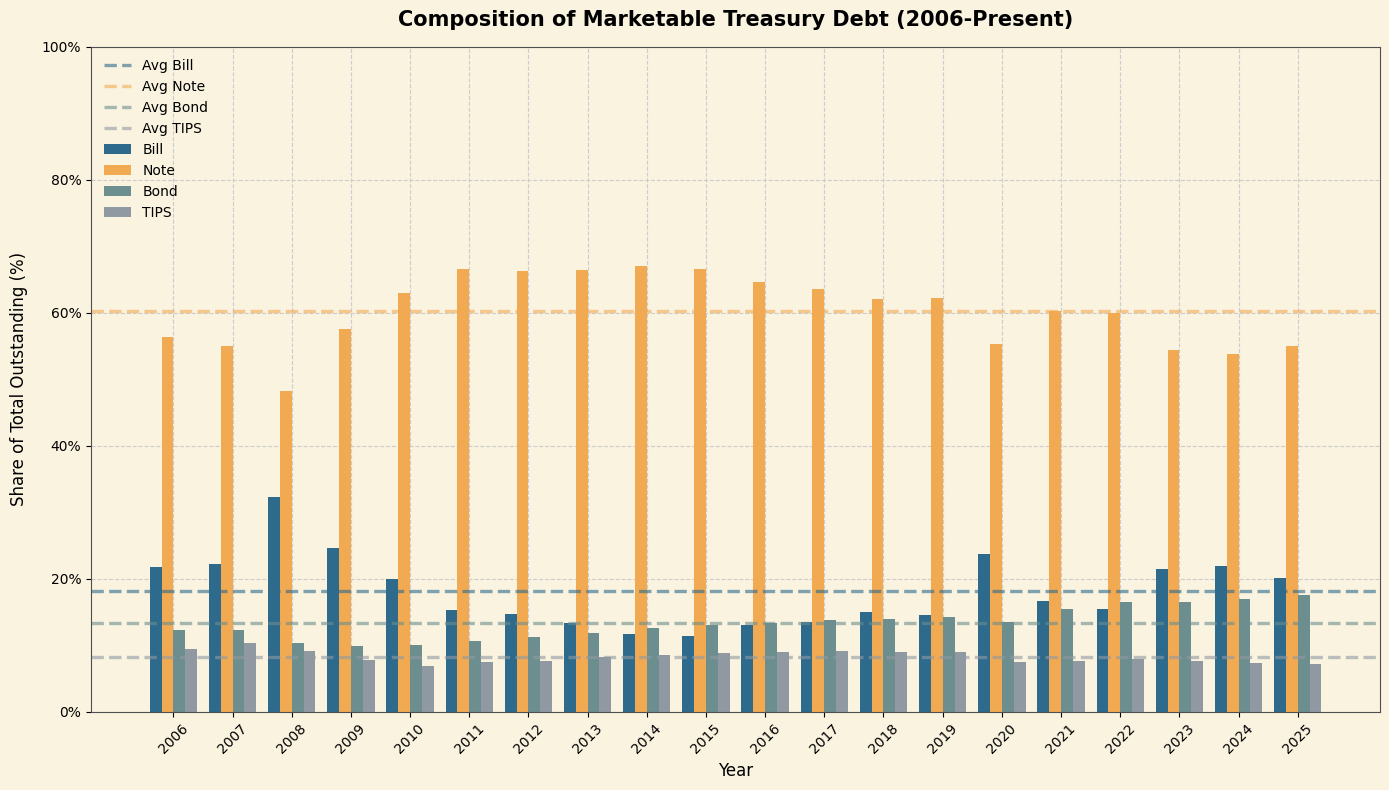

In [48]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from fredapi import Fred
from datetime import datetime
from matplotlib.ticker import PercentFormatter

##Retrieve the Data
base_url = "https://api.fiscaldata.treasury.gov/services/api/fiscal_service"
endpoint = "/v1/debt/mspd/mspd_table_1"

params = {
    "fields": "record_date,security_class_desc,total_mil_amt",
    "sort": "record_date",
    "page[size]": "10000",
    "filter": "record_date:gte:2006-01-01"
}

headers = {
    "User-Agent": "Mozilla/5.0",
    "Accept": "application/json"
}

url = f"{base_url}{endpoint}"
print("Request URL:", url)
response = requests.get(url, params=params, headers=headers)
#print("Response:", response)

if response.status_code != 200:
    print("Error fetching data:", response.status_code, response.text)
    exit()

json_response = response.json()
if "data" not in json_response:
    print("The JSON response does not contain a 'data' key:", json_response)
    exit()

data = json_response["data"]
df = pd.DataFrame(data)

# Convert record_date to datetime and total_mil_amt to numeric.
df["record_date"] = pd.to_datetime(df["record_date"])
df["total_mil_amt"] = pd.to_numeric(df["total_mil_amt"], errors="coerce")

# Print unique security_class_desc values.
unique_sec_types = set(df["security_class_desc"].unique())
print("Unique security_class_desc values in the dataset:")
#print(unique_sec_types)

# Part 2: Categorize by Security Type
#
def categorize_security_desc(desc):
    desc = desc.lower()
    if "bill" in desc:
        return "Bill"
    elif "note" in desc:
        return "Note"
    elif "bond" in desc:
        return "Bond"
    elif "inflation" in desc:  # Assuming this identifies TIPS
        return "Tips"
    else:
        return "Other"

df["category"] = df["security_class_desc"].apply(categorize_security_desc)
print("Data after categorization (first 5 rows):")
#print(df.head())

# Part 3: Get Year-End Outstanding Values
# Reset the index so that record_date is a column.
df_reset = df.reset_index(drop=True)
# Group by record_date and category, summing total_mil_amt for each day.
daily_pivot = df_reset.groupby(["record_date", "category"])["total_mil_amt"].sum().unstack(fill_value=0)
# daily_pivot now has one row per record_date with columns for each category.

# For each year, select the row with the maximum record_date (year-end snapshot).
daily_pivot["year"] = daily_pivot.index.year
annual_data = daily_pivot.groupby("year").apply(lambda g: g.loc[g.index.max()])
# Set the index to be the year.
annual_data.index = annual_data.index.get_level_values(0)
# Convert outstanding amounts from millions to dollars.
annual_data = annual_data * 1e6

print("Annual Outstanding Debt by Type (Year-End):")
print(annual_data.head())

# Extract the values for each category.
years = sorted(annual_data.index)
bills = annual_data.get("Bill", pd.Series(0, index=years))
notes = annual_data.get("Note", pd.Series(0, index=years))
bonds = annual_data.get("Bond", pd.Series(0, index=years))
tips = annual_data.get("Tips", pd.Series(0, index=years))

# Create a DataFrame that holds the absolute outstanding values.
abs_data = pd.DataFrame({
    "Bill": bills,
    "Note": notes,
    "Bond": bonds,
    "Tips": tips
}, index=years)

# Part 4: Compute Percentage Shares
# For each year, compute the percentage that each category contributes to the total outstanding debt.
total_outstanding = abs_data.sum(axis=1)
percent_data = abs_data.div(total_outstanding, axis=0) * 100

print("Percentage Share of Outstanding Debt by Type (Year-End):")
#print(percent_data.head())

# -----------------------------
# Part 5: Compute Average Percentage for Each Type
# -----------------------------
avg_bill = percent_data["Bill"].mean()
avg_note = percent_data["Note"].mean()
avg_bond = percent_data["Bond"].mean()
avg_tips = percent_data["Tips"].mean()

# -----------------------------
# Part 6: Plot the Percentage Shares as Grouped Bars with Average Lines
# -----------------------------
use_chart_style()                      # <-- Lato font, beige bg, palette

x = np.arange(len(years))
width = 0.20

# Choose four colors from your rcParams cycle
palette = plt.rcParams["axes.prop_cycle"].by_key()["color"]
c_bill, c_note, c_bond, c_tips = palette[:4]

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor("#FAF3E0")     # ensure figure-level beige

# Bars
ax.bar(x - 1.5*width, percent_data["Bill"], width, color=c_bill,  label="Bill")
ax.bar(x - 0.5*width, percent_data["Note"], width, color=c_note,  label="Note")
ax.bar(x + 0.5*width, percent_data["Bond"], width, color=c_bond,  label="Bond")
ax.bar(x + 1.5*width, percent_data["Tips"], width, color=c_tips,  label="TIPS")

# Average dashed lines (same colors, lighter alpha)
ax.axhline(avg_bill,  color=c_bill,  linestyle="--", alpha=.6, label="Avg Bill")
ax.axhline(avg_note,  color=c_note,  linestyle="--", alpha=.6, label="Avg Note")
ax.axhline(avg_bond,  color=c_bond,  linestyle="--", alpha=.6, label="Avg Bond")
ax.axhline(avg_tips,  color=c_tips,  linestyle="--", alpha=.6, label="Avg TIPS")

# Axis styling
ax.set_xlabel("Year",  fontsize=12)
ax.set_ylabel("Share of Total Outstanding (%)", fontsize=12, labelpad=10)
ax.set_title("Composition of Marketable Treasury Debt (2006-Present)",
             fontsize=15, fontweight="bold", pad=15)

ax.set_xticks(x)
ax.set_xticklabels(years, rotation=45)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(PercentFormatter())

# Grid behind bars
ax.grid(axis="y", linestyle="--")
ax.set_axisbelow(True)

# De-duplicate legend labels
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), loc="upper left", frameon=False)

plt.tight_layout()
plt.show()

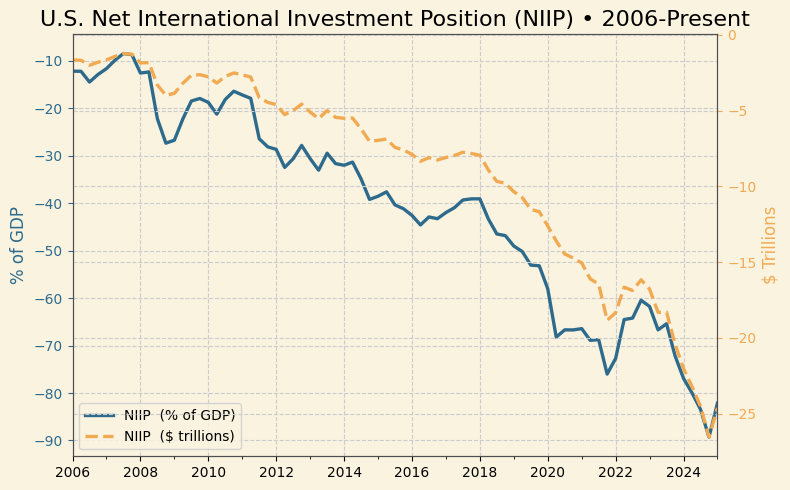

In [61]:

# U.S. NIIP since 1980  (level + % of GDP)  •  units fixed
from fredapi import Fred
import pandas as pd, matplotlib.pyplot as plt

use_chart_style()            # Lato font, beige bg, 4-color palette

fred   = Fred(api_key="b1b93f854d911b3cdc94df6dd9ec0365")
start  = "1980-01-01"

# NIIP level in **millions** → convert to billions
niip_bil = fred.get_series("IIPUSNETIQ", start) / 1_000   # $ billions
gdp_bil  = fred.get_series("GDP",        start)           # $ billions

df = pd.concat([
        niip_bil.rename("NIIP ($bn)"),
        (niip_bil / gdp_bil * 100).rename("NIIP % of GDP")
     ], axis=1).dropna()

fig, ax1 = plt.subplots(figsize=(8,5))
ax2 = ax1.twinx()

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
c_pct, c_lvl = colors[0], colors[1]

df["NIIP % of GDP"].plot(ax=ax1, color=c_pct, label="NIIP  (% of GDP)")
(df["NIIP ($bn)"] / 1_000).plot(           # → $ trillions
    ax=ax2, color=c_lvl, linestyle="--", label="NIIP  ($ trillions)"
)

# Axis labels / colors
ax1.set_ylabel("% of GDP", color=c_pct)
ax2.set_ylabel("$ Trillions", color=c_lvl)
ax1.tick_params(axis="y", colors=c_pct)
ax2.tick_params(axis="y", colors=c_lvl)

ax1.set_title("U.S. Net International Investment Position (NIIP) • 2006-Present")
ax1.grid(axis="y", linestyle="--")

# Merge legends
lines, labels   = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="lower left")

plt.show()

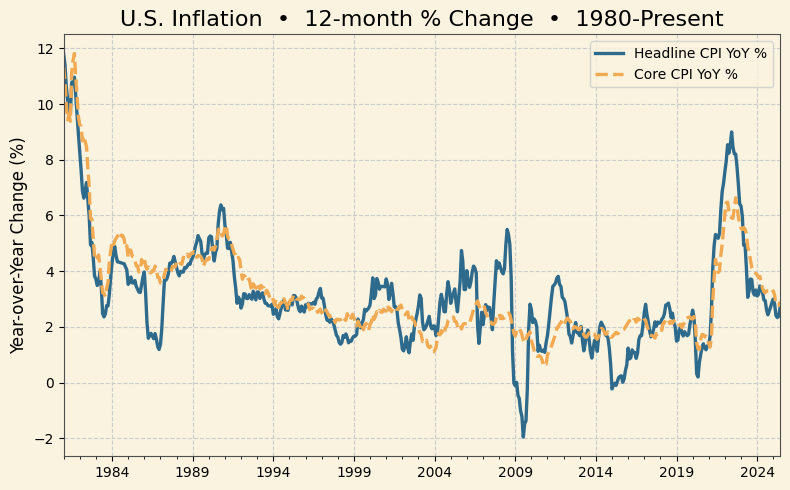

In [62]:
# U.S. Inflation since 1980  –  12-month % change (headline vs. core CPI)
from fredapi import Fred
import pandas as pd, matplotlib.pyplot as plt

use_chart_style()   # Lato + beige + 4-color palette

fred  = Fred(api_key="b1b93f854d911b3cdc94df6dd9ec0365")
start = "1980-01-01"

# Monthly CPI indexes (SA)
cpi   = fred.get_series("CPIAUCSL",  start)   # headline
core  = fred.get_series("CPILFESL",  start)   # core (ex-food/energy)

# 12-month % change
cpi_yoy  = (cpi.pct_change(12)  * 100).rename("Headline CPI YoY %")
core_yoy = (core.pct_change(12) * 100).rename("Core CPI YoY %")

df = pd.concat([cpi_yoy, core_yoy], axis=1).dropna()

fig, ax = plt.subplots(figsize=(8,5))

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
c_head, c_core = colors[0], colors[1]

df["Headline CPI YoY %"].plot(ax=ax, color=c_head,  label="Headline CPI YoY %")
df["Core CPI YoY %"]    .plot(ax=ax, color=c_core, linestyle="--", label="Core CPI YoY %")

ax.set_ylabel("Year-over-Year Change (%)")
ax.set_title("U.S. Inflation  •  12-month % Change  •  1980-Present")
ax.grid(axis="y", linestyle="--")
ax.legend(loc="upper right")

plt.show()

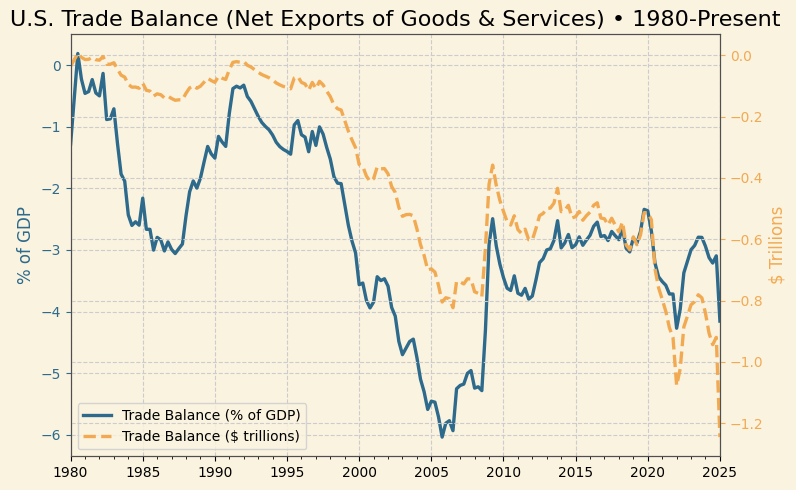

In [69]:

# U.S. Trade Balance (Net Exports)    1980-Present
from fredapi import Fred
import pandas as pd, matplotlib.pyplot as plt

use_chart_style()   # Lato font, beige BG, 4-color palette

fred  = Fred(api_key="b1b93f854d911b3cdc94df6dd9ec0365")
start = "1980-01-01"

# Quarterly Net Exports of Goods & Services (SAAR, $ bn)
trade_q = fred.get_series("NETEXP", start)                    # $ billions

# Quarterly nominal GDP ($ bn) – give it an explicit name
gdp_q   = fred.get_series("GDP", start).rename("GDP ($bn)")

# Combine and compute % of GDP
df = (pd.concat([trade_q.rename("Trade Bal ($bn)"), gdp_q], axis=1)
        .dropna())
df["Trade Bal % of GDP"] = df["Trade Bal ($bn)"] / df["GDP ($bn)"] * 100

# --- Plot ---------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(8,5))
ax2 = ax1.twinx()

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
c_pct, c_lvl = colors[0], colors[1]

# % of GDP (left axis)
df["Trade Bal % of GDP"].plot(ax=ax1, color=c_pct, label="Trade Balance (% of GDP)")

# Level in $ trillions (right axis)
(df["Trade Bal ($bn)"] / 1_000).plot(ax=ax2, color=c_lvl,
                                     linestyle="--", label="Trade Balance ($ trillions)")

# Axis labels/colors
ax1.set_ylabel("% of GDP", color=c_pct)
ax2.set_ylabel("$ Trillions", color=c_lvl)
ax1.tick_params(axis="y", colors=c_pct)
ax2.tick_params(axis="y", colors=c_lvl)

ax1.set_title("U.S. Trade Balance (Net Exports of Goods & Services) • 1980-Present")
ax1.grid(axis="y", linestyle="--")

# Merge legends
h1,l1 = ax1.get_legend_handles_labels()
h2,l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc="lower left")

plt.show()

/var/folders/43/9kgwqynj2f1b73147f7w9gj00000gn/T/ipykernel_52790/3459852161.py:14: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  bal_q = walcl.resample("Q").last()
/var/folders/43/9kgwqynj2f1b73147f7w9gj00000gn/T/ipykernel_52790/3459852161.py:22: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  ffr_q = fred.get_series("FEDFUNDS", start).resample("Q").last()


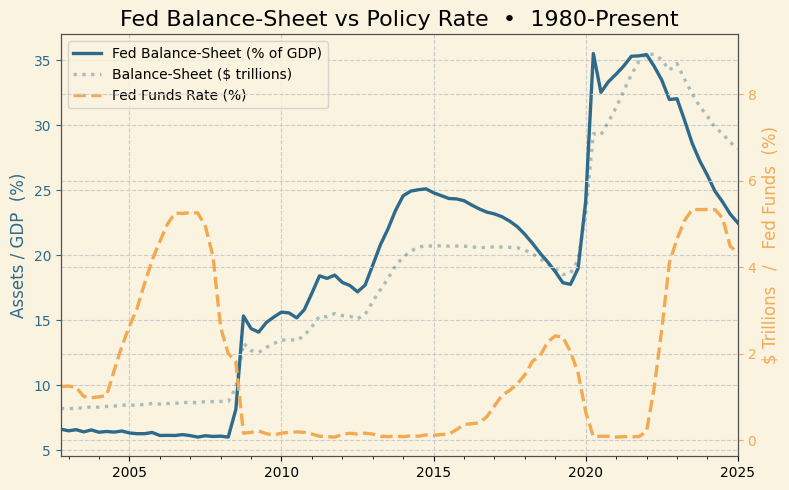

In [71]:
# Fed Balance-Sheet vs Fed-Funds Rate 1980-Present  (dates aligned)
from fredapi import Fred
import pandas as pd, matplotlib.pyplot as plt

use_chart_style()                         # Lato font, beige BG, house palette

fred  = Fred(api_key="b1b93f854d911b3cdc94df6dd9ec0365")
start = "1980-01-01"

# 1) Fed assets (WALCL weekly, $ millions) → $ billions, PeriodIndex Q
walcl = fred.get_series("WALCL", start) / 1_000          # → $ bn
bal_q = walcl.resample("Q").last()
bal_q.index = bal_q.index.to_period("Q")

# 2) Nominal GDP ($ bn, Q)  → PeriodIndex Q
gdp_q = fred.get_series("GDP", start)
gdp_q.index = gdp_q.index.to_period("Q")

# 3) Fed-funds rate (monthly, %) → quarterly last, PeriodIndex Q
ffr_q = fred.get_series("FEDFUNDS", start).resample("Q").last()
ffr_q.index = ffr_q.index.to_period("Q")

# 4) Combine & compute Assets-to-GDP
df = pd.concat({
        "Fed Assets ($bn)" : bal_q,
        "GDP ($bn)"        : gdp_q,
        "Fed Funds %"      : ffr_q
     }, axis=1).dropna()

df["Assets % of GDP"] = df["Fed Assets ($bn)"] / df["GDP ($bn)"] * 100

# Convert PeriodIndex back to timestamp (quarter-end) for plotting
df.index = df.index.to_timestamp("Q")

# --- Plot ---------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(8,5))
ax2 = ax1.twinx()

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
c_assets, c_ffr = colors[0], colors[1]

df["Assets % of GDP"].plot(ax=ax1, color=c_assets,
                           label="Fed Balance-Sheet (% of GDP)")
(df["Fed Assets ($bn)"]/1_000).plot(ax=ax2, color=c_assets,
                                    linestyle=":", alpha=.4,
                                    label="Balance-Sheet ($ trillions)")
df["Fed Funds %"].plot(ax=ax2, color=c_ffr, linestyle="--",
                       label="Fed Funds Rate (%)")

# Styling
ax1.set_ylabel("Assets / GDP  (%)", color=c_assets)
ax2.set_ylabel("$ Trillions   /   Fed Funds  (%)", color=c_ffr)
ax1.tick_params(axis="y", colors=c_assets)
ax2.tick_params(axis="y", colors=c_ffr)

ax1.set_title("Fed Balance-Sheet vs Policy Rate  •  1980-Present")
ax1.grid(axis="y", linestyle="--")

# Merge legends
h1,l1 = ax1.get_legend_handles_labels()
h2,l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc="upper left")

plt.show()

TRY skipped – Bad Request.  The series does not exist.


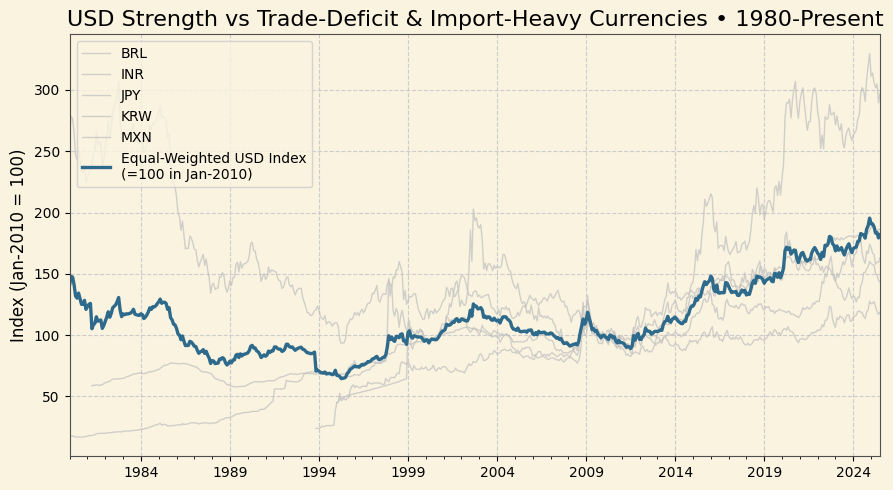

In [77]:
# USD vs Trade-Deficit (and high-import) EM/Asia FX Basket • Jan-2010 = 100
from fredapi import Fred
import pandas as pd, matplotlib.pyplot as plt

use_chart_style()                    # Lato, beige, deep-blue palette

fred   = Fred(api_key="b1b93f854d911b3cdc94df6dd9ec0365")
start  = "1980-01-01"

series_dict = {
    "BRL": "DEXBZUS",   # Brazil
    "INR": "DEXINUS",   # India
    "TRY": "DEXTAIUS",  # Turkey
    "MXN": "DEXMXUS",   # Mexico
    "JPY": "DEXJPUS",   # Japan (large trade deficit since 2014-15)
    "KRW": "DEXKOUS",   # Korea
}

monthly = {}
for code, fid in series_dict.items():
    try:
        s = fred.get_series(fid, observation_start=start)
        if s.empty:
            raise ValueError("no data")
        monthly[code] = s.resample("ME").last()  # month-end
    except Exception as e:
        print(f"{code} skipped – {e}")

df = pd.DataFrame(monthly).dropna(how="all")
if df.empty:
    raise RuntimeError("No FX series downloaded.")

# Normalise to 100 at Jan-2010 (or first row if missing)
base_date = pd.Timestamp("2010-01-31")
if base_date not in df.index:
    base_date = df.index[0]
df_norm = df / df.loc[base_date] * 100

# Equal-weighted composite
df_norm["Composite"] = df_norm.mean(axis=1)

# ── Plot ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9,5))
colors  = plt.rcParams["axes.prop_cycle"].by_key()["color"]
c_comp  = colors[0]

# Light-grey individual lines (USD vs each FX)
components = df_norm.columns.difference(["Composite"])
df_norm[components].plot(ax=ax, color="#BFBFBF",
                         linewidth=1, alpha=.7, legend=False)

# Deep-blue composite
df_norm["Composite"].plot(ax=ax, color=c_comp, linewidth=2.4,
                          label="Equal-Weighted USD Index\n(=100 in Jan-2010)")

ax.set_ylabel("Index (Jan-2010 = 100)")
ax.set_title("USD Strength vs Trade-Deficit & Import-Heavy Currencies • 1980-Present")
ax.grid(axis="y", linestyle="--")
ax.legend(loc="upper left")

plt.show()

Composite yearly:
2015-12-31    103.677746
2016-12-31    108.199934
2017-12-31    120.700720
2018-12-31    123.039443
2019-12-31    135.456200
Freq: YE-DEC, dtype: float64

...

2021-12-31    177.326169
2022-12-31    166.169367
2023-12-31    179.760316
2024-12-31    204.211101
2025-12-31    204.959461
Freq: YE-DEC, dtype: float64
Share series:
Series([], Name: % US of Global Stock-Mkt Cap, dtype: float64)

...

Series([], Name: % US of Global Stock-Mkt Cap, dtype: float64)

Merged combo shape: (0, 2)


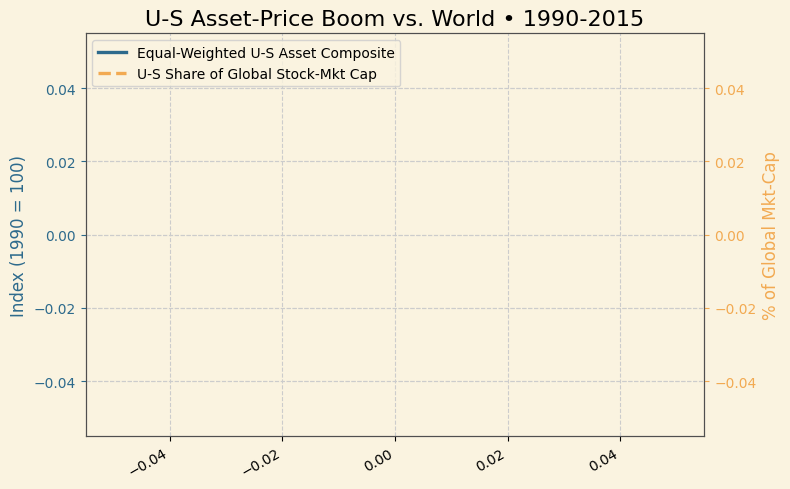

In [98]:
# U-S All-Asset Composite  •  1990-2015
# Overlay: U-S Share of Global Stock-Market Cap   (all FRED)
from fredapi import Fred
import pandas as pd, matplotlib.pyplot as plt

use_chart_style()
fred  = Fred(api_key="b1b93f854d911b3cdc94df6dd9ec0365")
start = "1990"

# 1) EQUAL-WEIGHTED COMPOSITE  ------------------------------------------------
stocks = fred.get_series("SP500",           start)
bonds  = fred.get_series("BAMLCC0A0CMTRIV", start)
houses = fred.get_series("CSUSHPINSA",      start)

df      = pd.concat([stocks, bonds, houses], axis=1).dropna()
df.columns = ["Stocks", "Bonds", "Housing"]
df_norm = df.div(df.iloc[0]).mul(100)              # re-base to 100
cmp_y   = df_norm.mean(axis=1).resample("YE").last()  # one value 31-Dec

# 2) MARKET-CAP SHARE  --------------------------------------------------------
us_pct  = fred.get_series("DDDM01USA156NWDB",  start)      # %
wld_pct = fred.get_series("DDDM011WA156NWDB", start)      # %  ← correct

# move both ratios to 31-Dec
us_pct.index  = pd.to_datetime(us_pct.index.year,  format="%Y") + pd.offsets.YearEnd()
wld_pct.index = pd.to_datetime(wld_pct.index.year, format="%Y") + pd.offsets.YearEnd()

us_gdp = (fred.get_series("GDP", start)               # SAAR $ bn, quarterly
            .resample("YE").last() / 4)               # annual $ bn

wld_gdp = (fred.get_series("NYGDPMKTPCDWLD", start)   # $ current, annual
             / 1e9).reindex(wld_pct.index)

us_cap  = us_pct  * us_gdp  / 100                     # $ bn
wld_cap = wld_pct * wld_gdp / 100                    # $ bn
share   = (us_cap / wld_cap * 100).rename("% US of Global Stock-Mkt Cap").dropna()

# --- DEBUG PRINTS -----------------------------------------------------------
print("Composite yearly:", cmp_y.head(), "\n...\n", cmp_y.tail(), sep="\n")
print("Share series:",    share.head(),  "\n...\n", share.tail(),  sep="\n")
combo = pd.concat([cmp_y, share], axis=1, join="inner")
print("\nMerged combo shape:", combo.shape)

# 3) PLOT --------------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(8,5)); ax2 = ax1.twinx()
c0, c1 = plt.rcParams["axes.prop_cycle"].by_key()["color"][:2]

combo.iloc[:,0].plot(ax=ax1, color=c0, label="Equal-Weighted U-S Asset Composite")
combo.iloc[:,1].plot(ax=ax2, color=c1, linestyle="--",
                     label="U-S Share of Global Stock-Mkt Cap")

ax1.set_ylabel("Index (1990 = 100)", color=c0)
ax2.set_ylabel("% of Global Mkt-Cap", color=c1)
ax1.tick_params(axis="y", colors=c0); ax2.tick_params(axis="y", colors=c1)
ax1.set_title("U-S Asset-Price Boom vs. World • 1990-2015")
ax1.grid(axis="y", linestyle="--")

h1,l1 = ax1.get_legend_handles_labels(); h2,l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc="upper left")
plt.show()

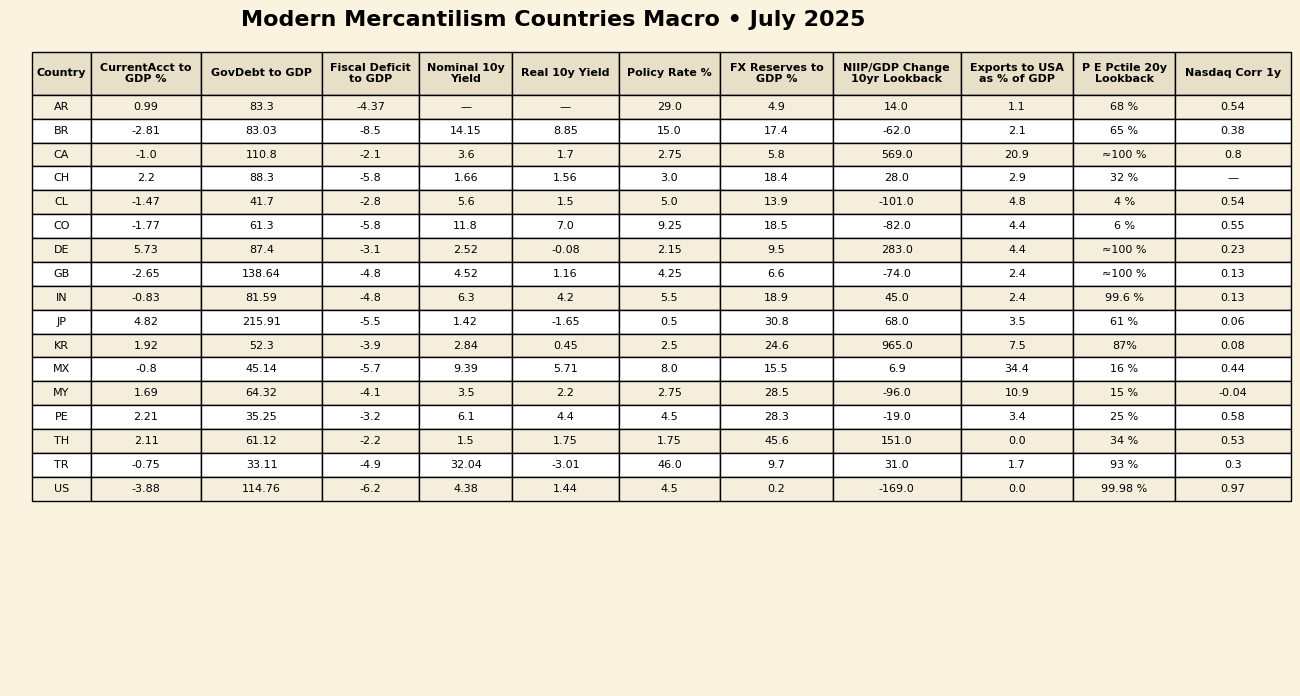

In [108]:
# Cross-Country Macro & Market Scorecard  (trimmed cols, uniform header height)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import textwrap

use_chart_style()  # your beige/Lato theme

data = [
    ["AR",  0.99, 83.3,  -4.37,   np.nan,  np.nan, 29.00,  4.9,  14,   1.1, "68 %",    0.54],
    ["BR", -2.81, 83.03, -8.50,  14.15,    8.85,  15.00, 17.4,  -62,   2.1, "65 %",    0.38],
    ["CA", -1.00,110.8,  -2.10,   3.60,    1.70,   2.75,  5.8, 569,  20.9,  "≈100 %",  0.80],
    ["CH",  2.20, 88.3,  -5.80,   1.66,    1.56,   3.00, 18.4,         28,   2.9, "32 %",     "—"],
    ["CL", -1.47, 41.7,  -2.80,   5.60,    1.50,   5.00, 13.9,      -101,   4.8,   "4 %",     0.54],
    ["CO", -1.77, 61.3,  -5.80,  11.80,    7.00,   9.25, 18.5,        -82,    4.4, "6 %",     0.55],
    ["DE",  5.73, 87.4,  -3.10,   2.52,   -0.08,   2.15,  9.5,     283,    4.4,    "≈100 %",  0.23],
    ["GB", -2.65,138.64, -4.80,   4.52,    1.16,   4.25,  6.6,-74,    2.4, "≈100 %",  0.13],
    ["IN", -0.83, 81.59, -4.80,   6.30,    4.20,   5.50, 18.9,  45,    2.4, "99.6 %",  0.13],
    ["JP",  4.82,215.91, -5.50,   1.42,   -1.65,   0.50, 30.8,     68,    3.5,      "61 %",    0.06],
    ["KR",  1.92, 52.3,  -3.90,   2.84,    0.45,   2.50, 24.6, 965,    7.5, "87%",     0.08],
    ["MX", -0.80, 45.14, -5.70,   9.39,    5.71,   8.00, 15.5,  6.9,  34.4,  "16 %",    0.44],
    ["MY",  1.69, 64.32, -4.10,   3.50,    2.20,   2.75, 28.5,  -96,  10.9,   "15 %",   -0.04],
    ["PE",  2.21, 35.25, -3.20,   6.10,    4.40,   4.50, 28.3, -19,   3.4,  "25 %",    0.58],
    ["TH",  2.11, 61.12, -2.20,   1.50,    1.75,   1.75, 45.6, 151,   0,            "34 %",    0.53],
    ["TR", -0.75, 33.11, -4.90,  32.04,   -3.01,  46.00,  9.7, 31,   1.7,  "93 %",    0.30],
    ["US", -3.88,114.76, -6.20,   4.38,    1.44,   4.50,  0.2,-169, 0,            "99.98 %", 0.97],
]

cols = [
    "Country","CurrentAcct_to_GDP_%","GovDebt_to_GDP","Fiscal_Deficit_to_GDP",
    "Nominal_10y_Yield","Real_10y_Yield","Policy_Rate_%","FX_Reserves_to_GDP_%",
    "NIIP/GDP_Change_10yr_Lookback","Exports_to_USA_as_%_of_GDP",
    "P_E_Pctile_20y_Lookback","Nasdaq_Corr_1y"
]

df = pd.DataFrame(data, columns=cols).fillna("—")

# ---- figure size (tweak if needed) ---------------------------------------
nrows = len(df)
fig_h = 0.32 * nrows + 1.6
fig_w = 13.5

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
fig.patch.set_facecolor("#FAF3E0")
ax.axis("off")

# ---- create table --------------------------------------------------------
tbl = ax.table(cellText=df.astype(str).values.tolist(),
               colLabels=df.columns,  # raw labels; we'll wrap next
               cellLoc="center", colLoc="center",
               loc="upper left")

tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.2)

# ---- wrap headers & give uniform height ----------------------------------
max_chars = 16
header_row = 0
base_h     = tbl[0, 0].get_height()
line_counts = []

for c, label in enumerate(df.columns):
    wrapped = "\n".join(textwrap.wrap(label.replace("_"," "), max_chars))
    cell = tbl[header_row, c]
    cell.get_text().set_text(wrapped)
    cell.get_text().set_weight("bold")
    cell.get_text().set_va("center")

    line_counts.append(wrapped.count("\n") + 1)

# tallest header
target_h = base_h * max(line_counts) * 0.9
for c in range(len(df.columns)):
    tbl[header_row, c].set_height(target_h)

width_scores = []
for i, col in enumerate(df.columns):
    max_body = df[col].astype(str).map(len).max()
    max_head = len(df.columns[i])
    width_scores.append(max(max_body, max_head))

widths = (np.array(width_scores) / sum(width_scores))

try:
    tbl.auto_set_column_width(col=list(range(len(df.columns))))
    for (r, c), cell in tbl.get_celld().items():
        cell.set_width(widths[c])
except Exception:
    pass

for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#E8DFC8")
    elif r % 2 == 1:
        cell.set_facecolor("#F6EEDD")

ax.set_title("Modern Mercantilism Countries Macro • July 2025",
             y=1.02, pad=0, fontweight="bold")

plt.tight_layout()
# plt.savefig("macro_scorecard_trimmed.png", dpi=300, bbox_inches="tight")
plt.show()

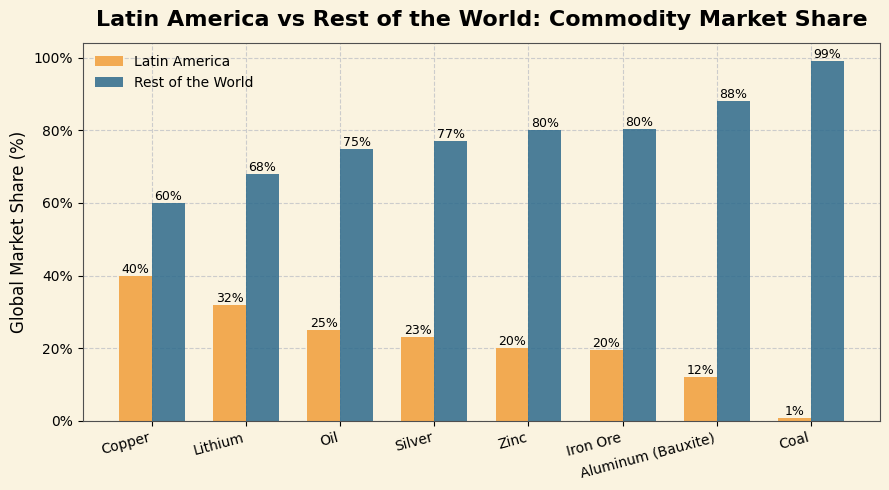

In [115]:
# Latin America vs Rest of World: Commodity Market Share  (incl. Iron, Aluminum, Coal)
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

try:
    use_chart_style()
except NameError:
    def use_chart_style():
        import matplotlib as mpl
        from cycler import cycler
        mpl.rcParams.update({
            "font.family": "sans-serif",
            "font.sans-serif": ["Lato", "DejaVu Sans"],
            "axes.prop_cycle": cycler(color=["#2D6A8C", "#F2AA52", "#6C8EAD", "#C97C5D"]),
            "axes.titlesize": 16,
            "axes.labelsize": 12,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "lines.linewidth": 2.4,
            "grid.color": "#CCCCCC",
            "grid.linestyle": "--",
            "axes.grid": True,
            "figure.facecolor": "#FAF3E0",
            "axes.facecolor":  "#FAF3E0",
            "savefig.facecolor": "#FAF3E0",
            "figure.autolayout": True,
        })
use_chart_style()

commodities = ["Copper","Lithium","Oil","Silver","Zinc"]
latam_pct   = [40,       32,       25,   23,     20]

latam_extra = {
    "Iron Ore": 19.6,     # TODO: replace with precise % of global production
    "Aluminum (Bauxite)": 12,   # "
    "Coal": 0.8,          # "
}

# combine
for k,v in latam_extra.items():
    commodities.append(k)
    latam_pct.append(v)

# compute RoW as 100 - LatAm
row_pct = [100 - x for x in latam_pct]

df = pd.DataFrame({
    "Commodity": commodities,
    "Latin America": latam_pct,
    "Rest of the World": row_pct
}).set_index("Commodity")

fig, ax = plt.subplots(figsize=(9,5))
fig.patch.set_facecolor("#FAF3E0")

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
c_lat, c_row = colors[1], colors[0]

x = np.arange(len(df))
w = 0.35

b1 = ax.bar(x - w/2, df["Latin America"],  width=w, label="Latin America", color=c_lat)
b2 = ax.bar(x + w/2, df["Rest of the World"], width=w, label="Rest of the World", color=c_row, alpha=.85)

ax.set_ylabel("Global Market Share (%)")
ax.set_title("Latin America vs Rest of the World: Commodity Market Share", pad=12, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(df.index, rotation=15, ha="right")
ax.yaxis.set_major_formatter(PercentFormatter())

ax.grid(axis="y", linestyle="--")
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="upper left")

# value labels
for bar in list(b1)+list(b2):
    ax.annotate(f"{bar.get_height():.0f}%",
                (bar.get_x()+bar.get_width()/2, bar.get_height()),
                ha="center", va="bottom", fontsize=9)

plt.show()

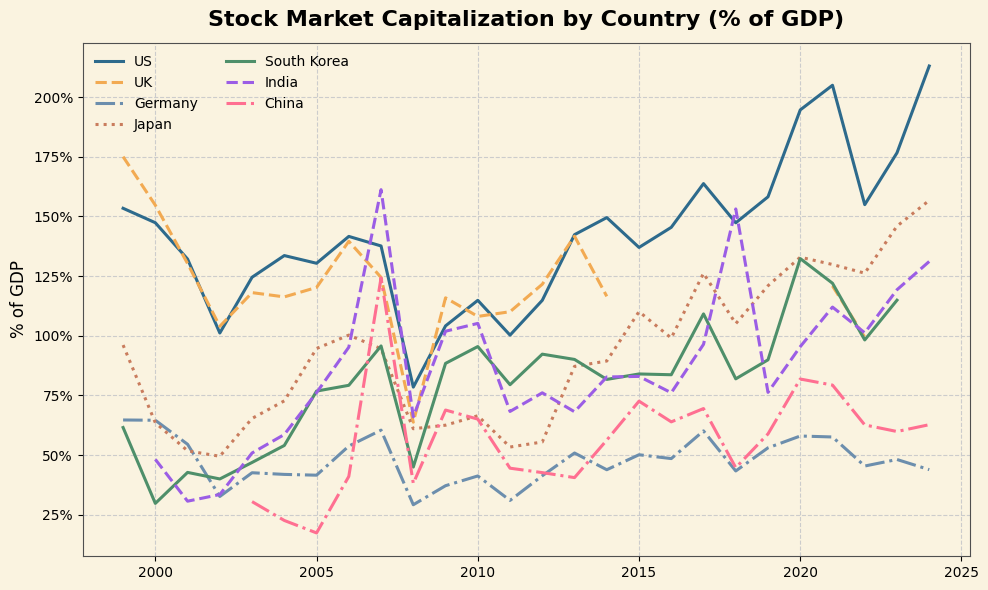

In [113]:
# World – Stock Market Capitalization by Country (% of GDP)
# Source: World Bank indicator CM.MKT.LCAP.GD.ZS
import requests, pandas as pd, matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

try:
    use_chart_style()
except NameError:
    def use_chart_style():
        import matplotlib as mpl
        from cycler import cycler
        mpl.rcParams.update({
            "font.family": "sans-serif",
            "font.sans-serif": ["Lato", "DejaVu Sans"],
            "axes.prop_cycle": cycler(color=["#2D6A8C","#F2AA52","#6C8EAD","#C97C5D",
                                             "#4E8F6A","#9B5DE5","#FF6F91","#FF9671",
                                             "#FFC75F","#0089BA"]),
            "axes.titlesize": 16,
            "axes.labelsize": 12,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "lines.linewidth": 2.2,
            "grid.color": "#CCCCCC",
            "grid.linestyle": "--",
            "axes.grid": True,
            "figure.facecolor": "#FAF3E0",
            "axes.facecolor":  "#FAF3E0",
            "savefig.facecolor": "#FAF3E0",
            "figure.autolayout": True,
        })
use_chart_style()

# --- Countries & WB codes --------------------------------------------------
countries = {
    "US"          : "USA",
    "UK"          : "GBR",
    "Germany"     : "DEU",
    "Japan"       : "JPN",
    "South Korea" : "KOR",
    "India"       : "IND",
    "China"       : "CHN",
}

indicator = "CM.MKT.LCAP.GD.ZS"
start_year, end_year = 1999, 2024

def fetch_wb_series(country_iso):
    """Return a pandas Series (year -> value) for one country."""
    url = f"https://api.worldbank.org/v2/country/{country_iso}/indicator/{indicator}"
    params = {"date": f"{start_year}:{end_year}", "per_page": 20000, "format": "json"}
    r = requests.get(url, params=params)
    r.raise_for_status()
    j = r.json()
    if len(j) < 2: 
        return pd.Series(dtype="float64")
    rows = j[1]
    ser = pd.Series({int(row["date"]): row["value"] for row in rows if row["value"] is not None})
    return ser.sort_index()

# Pull & combine
dfs = []
for name, iso in countries.items():
    try:
        s = fetch_wb_series(iso)
        if not s.empty:
            dfs.append(s.rename(name))
        else:
            print(f"{name}: no data returned.")
    except Exception as e:
        print(f"{name}: error {e}")

df = pd.concat(dfs, axis=1)

fig, ax = plt.subplots(figsize=(10,6))
fig.patch.set_facecolor("#FAF3E0")

# Distinct colors (12 soft-but-separated hues)
palette = [
    "#2D6A8C", "#F2AA52", "#6C8EAD", "#C97C5D", "#4E8F6A",
    "#9B5DE5", "#FF6F91", "#0089BA", "#6A4C93", "#FFBE0B",
    "#3A86FF", "#8338EC"
]
# Matching line styles to guarantee differentiation
linestyles = ["-","--","-.",":","-","--","-.",":","-","--","-.",":"]

for i, col in enumerate(df.columns):
    df[col].plot(ax=ax,
                 color=palette[i % len(palette)],
                 linestyle=linestyles[i % len(linestyles)],
                 linewidth=2.2,
                 label=col)

ax.set_ylabel("% of GDP")
ax.set_title("Stock Market Capitalization by Country (% of GDP)",
             fontweight="bold", pad=12)
ax.yaxis.set_major_formatter(PercentFormatter())

ax.grid(axis="y", linestyle="--")
ax.set_axisbelow(True)
ax.legend(loc="upper left", ncol=2, frameon=False)

plt.show()

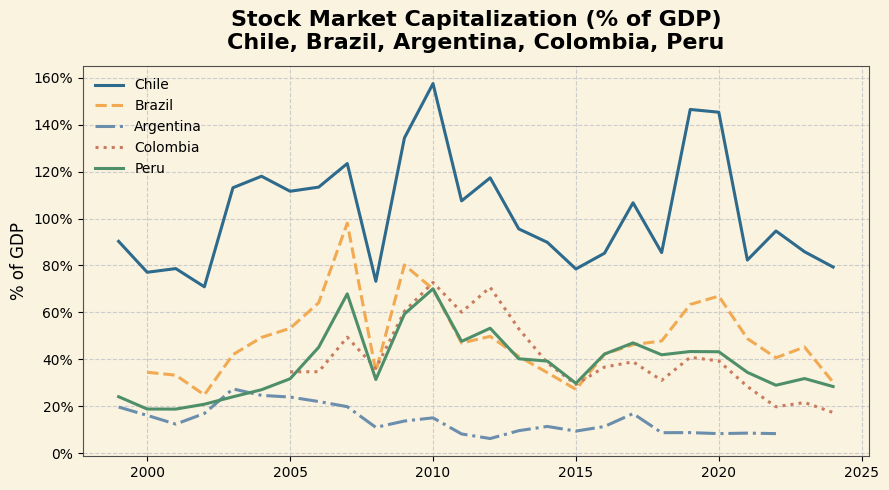

In [114]:
#
# Latin America – Stock Market Cap (% of GDP)  | World Bank CM.MKT.LCAP.GD.ZS
import requests, pandas as pd, matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

try:
    use_chart_style()
except NameError:
    def use_chart_style():
        import matplotlib as mpl
        from cycler import cycler
        mpl.rcParams.update({
            "font.family": "sans-serif",
            "font.sans-serif": ["Lato", "DejaVu Sans"],
            "axes.prop_cycle": cycler(color=["#2D6A8C","#F2AA52","#6C8EAD","#C97C5D",
                                             "#4E8F6A","#9B5DE5","#FF6F91","#FF9671",
                                             "#FFC75F","#0089BA"]),
            "axes.titlesize": 16,
            "axes.labelsize": 12,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "lines.linewidth": 2.2,
            "grid.color": "#CCCCCC",
            "grid.linestyle": "--",
            "axes.grid": True,
            "figure.facecolor": "#FAF3E0",
            "axes.facecolor":  "#FAF3E0",
            "savefig.facecolor": "#FAF3E0",
            "figure.autolayout": True,
        })
use_chart_style()

# --- Countries & codes -----------------------------------------------------
countries = {
    "Chile"     : "CHL",
    "Brazil"    : "BRA",
    "Argentina" : "ARG",
    "Colombia"  : "COL",
    "Peru"      : "PER",
}

indicator = "CM.MKT.LCAP.GD.ZS"
start_year, end_year = 1999, 2024

def fetch_wb_series(iso):
    url = f"https://api.worldbank.org/v2/country/{iso}/indicator/{indicator}"
    params = {"date": f"{start_year}:{end_year}", "per_page": 20000, "format": "json"}
    r = requests.get(url, params=params)
    r.raise_for_status()
    j = r.json()
    if len(j) < 2: 
        return pd.Series(dtype="float64")
    rows = j[1]
    ser = pd.Series({int(row["date"]): row["value"] for row in rows if row["value"] is not None})
    return ser.sort_index()

# pull data
series_list = []
for name, iso in countries.items():
    s = fetch_wb_series(iso)
    if s.empty:
        print(f"{name}: no data.")
    else:
        series_list.append(s.rename(name))

df = pd.concat(series_list, axis=1)

# --- Plot ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9,5))
fig.patch.set_facecolor("#FAF3E0")

palette = ["#2D6A8C","#F2AA52","#6C8EAD","#C97C5D","#4E8F6A"]
linestyles = ["-","--","-.",":","-"]

for i, col in enumerate(df.columns):
    df[col].plot(ax=ax,
                 color=palette[i % len(palette)],
                 linestyle=linestyles[i % len(linestyles)],
                 linewidth=2.2,
                 label=col)

ax.set_ylabel("% of GDP")
ax.set_title("Stock Market Capitalization (% of GDP)\nChile, Brazil, Argentina, Colombia, Peru",
             fontweight="bold", pad=12)
ax.yaxis.set_major_formatter(PercentFormatter())

ax.grid(axis="y", linestyle="--")
ax.set_axisbelow(True)
ax.legend(loc="upper left", frameon=False)

plt.show()